In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [47]:
df = pd.read_excel('1.flight_price.xlsx')

In [48]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [50]:
df.columns = [x.lower() for x in df.columns]

In [51]:
df['airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [108]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
sparx_matrix_airline = encoder.fit_transform(df[['airline']]).toarray()
airline_sample_df = pd.DataFrame(sparx_matrix_airline, columns=encoder.get_feature_names_out())
airline_sample_df

,airline_Air Asia,airline_Air India,airline_GoAir,airline_IndiGo,airline_Jet Airways,airline_Jet Airways Business,airline_Multiple carriers,airline_Multiple carriers Premium economy,airline_SpiceJet,airline_Trujet,airline_Vistara,airline_Vistara Premium economy
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10680,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Handling Missing value

In [52]:
df.isnull().sum()

airline            0
date_of_journey    0
source             0
destination        0
route              1
dep_time           0
arrival_time       0
duration           0
total_stops        1
additional_info    0
price              0
dtype: int64

In [53]:
df['route'] = df['route'].fillna(df['route'].mode()[0])

In [54]:
df['total_stops'] = df['total_stops'].fillna(df['total_stops'].mode()[0])

### checking any Duplicate value exist or not ?

In [55]:
df.duplicated().sum() # although it contain 220 duplicate value but I am not going to change them bcz it's common as per this Domain

np.int64(220)

In [56]:
df.shape

(10683, 11)

In [57]:
df.head()

,airline,date_of_journey,source,destination,route,dep_time,arrival_time,duration,total_stops,additional_info,price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### checking Target value distribution

<Axes: xlabel='price', ylabel='Count'>

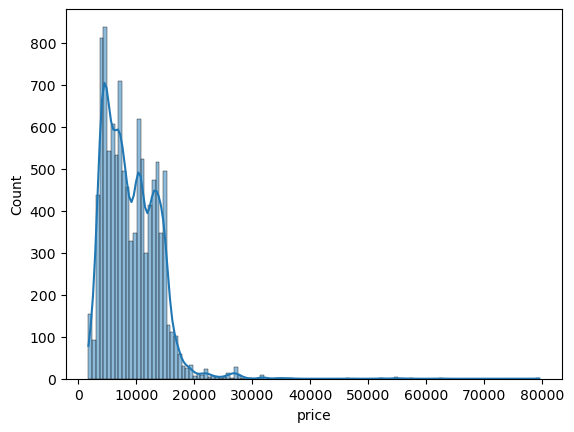

In [58]:
sns.histplot(x='price', data=df, kde=True) # So, price is Right skewwed distribution.

<Axes: xlabel='price'>

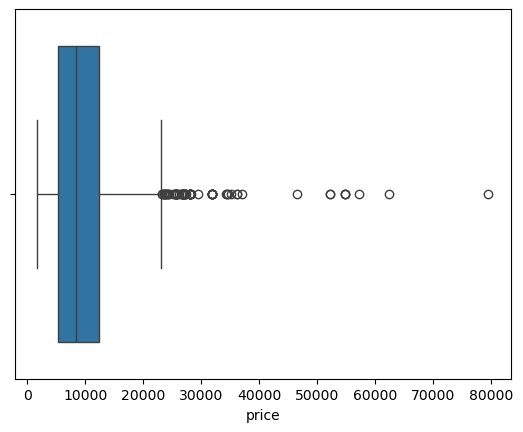

In [59]:
sns.boxplot(x='price', data=df) # yes, The target value contain many outliers

### Now checking the correlation of the data


In [60]:
#df.corr() # we can't check correlation because all attributes are conatain object type of data

### Converting categorical data into numerical data

In [61]:
df.columns

Index(['airline', 'date_of_journey', 'source', 'destination', 'route',
       'dep_time', 'arrival_time', 'duration', 'total_stops',
       'additional_info', 'price'],
      dtype='object')

In [62]:
df['airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [63]:
df['source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [64]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [65]:
source_sparx_matrix = encoder.fit_transform(df[['source']]).toarray()
source_sample_df = pd.DataFrame(source_sparx_matrix, columns=encoder.get_feature_names_out())
# df = pd.concat([df, source_sample_df], axis=1)

In [66]:
source_sample_df.head()

,source_Banglore,source_Chennai,source_Delhi,source_Kolkata,source_Mumbai
0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0


In [67]:
destination_sparx_matrix = encoder.fit_transform(df[['destination']]).toarray()
destination_sample_df = pd.DataFrame(destination_sparx_matrix, columns=encoder.get_feature_names_out())
# df = pd.concat([df, destination_sample_df], axis=1)

In [68]:
destination_sample_df.head()

,destination_Banglore,destination_Cochin,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_New Delhi
0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0


In [69]:
df.columns

Index(['airline', 'date_of_journey', 'source', 'destination', 'route',
       'dep_time', 'arrival_time', 'duration', 'total_stops',
       'additional_info', 'price'],
      dtype='object')

In [70]:
df['total_stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [71]:
dic = {
    'non-stop' : 0,
    '2 stops' : 2,
    '1 stop' : 1,
    '3 stops' : 3,
    '4 stops' : 4
}
print(dic)

{'non-stop': 0, '2 stops': 2, '1 stop': 1, '3 stops': 3, '4 stops': 4}


In [72]:
df['total_stops'] = df['total_stops'].map(dic)

In [73]:
df['total_stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: total_stops, Length: 10683, dtype: int64

In [74]:
df['additional_info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [75]:
df['additional_info'] = df['additional_info'].map(df.groupby('additional_info')['price'].mean().to_dict())

In [76]:
df['additional_info']

0        9141.320192
1        9141.320192
2        9141.320192
3        9141.320192
4        9141.320192
            ...     
10678    9141.320192
10679    9141.320192
10680    9141.320192
10681    9141.320192
10682    9141.320192
Name: additional_info, Length: 10683, dtype: float64

In [77]:
all_duration = df['duration'].unique()

In [78]:
time_dict = {}
for time in all_duration:
    total_time = 0
    if len(time.strip().split(' ')) > 1:
        hour = int(time.strip().split('h')[0])
        minute = int(time.strip().split('h')[1].split('m')[0].strip())
        total_time = (hour*60) + minute
    else:
        if time.strip()[-1] == 'h':
            total_time = int(time.strip().split('h')[0]) * 60
        else:
            total_time = int(time.strip().split('m')[0])
    time_dict[time] = total_time

In [79]:
df['duration'] = df['duration'].map(time_dict)

In [80]:
df.head()

,airline,date_of_journey,source,destination,route,dep_time,arrival_time,duration,total_stops,additional_info,price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,170,0,9141.320192,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,445,2,9141.320192,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,1140,2,9141.320192,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,325,1,9141.320192,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,285,1,9141.320192,13302


In [81]:
len(df['arrival_time'].unique())

1343

In [86]:
df['dep_time_hour'] = ( df['dep_time'].str.split(':').str[0].astype('int') )
df['dep_time_munite'] = ( df['dep_time'].str.strip().str.split(':').str[1].astype('int') )
df.drop('dep_time', axis=1, inplace=True)

In [88]:
df['arrival_time_hour'] = ( df['arrival_time'].str.strip().str.split(" ").str[0].str.split(':').str[0].astype('int') )
df['arrival_time_minute'] = (df['arrival_time'].str.strip().str.split(" ").str[0].str.split(':').str[1].astype('int'))
df.drop('arrival_time', axis=1, inplace=True)

In [100]:
df.head()

,airline,source,destination,route,duration,total_stops,additional_info,price,dep_time_hour,dep_time_munite,arrival_time_hour,arrival_time_minute,date,month,year
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,0,9141.320192,3897,22,20,1,10,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,9141.320192,7662,5,50,13,15,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2,9141.320192,13882,9,25,4,25,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1,9141.320192,6218,18,5,23,30,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1,9141.320192,13302,16,50,21,35,1,3,2019


In [98]:
df['date'] = df['date_of_journey'].str.strip().str.split('/').str[0].astype(int)
df['month'] = df['date_of_journey'].str.strip().str.split('/').str[1].astype(int)
df['year'] = df['date_of_journey'].str.strip().str.split('/').str[2].astype(int)
df.drop('date_of_journey', axis=1, inplace=True)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   airline              10683 non-null  object 
 1   source               10683 non-null  object 
 2   destination          10683 non-null  object 
 3   route                10683 non-null  object 
 4   duration             10683 non-null  int64  
 5   total_stops          10683 non-null  int64  
 6   additional_info      10683 non-null  float64
 7   price                10683 non-null  int64  
 8   dep_time_hour        10683 non-null  int64  
 9   dep_time_munite      10683 non-null  int64  
 10  arrival_time_hour    10683 non-null  int64  
 11  arrival_time_minute  10683 non-null  int64  
 12  date                 10683 non-null  int64  
 13  month                10683 non-null  int64  
 14  year                 10683 non-null  int64  
dtypes: float64(1), int64(10), object(4)


In [101]:
df.drop('route', axis=1, inplace=True)

In [102]:
df.head(2)

,airline,source,destination,duration,total_stops,additional_info,price,dep_time_hour,dep_time_munite,arrival_time_hour,arrival_time_minute,date,month,year
0,IndiGo,Banglore,New Delhi,170,0,9141.320192,3897,22,20,1,10,24,3,2019
1,Air India,Kolkata,Banglore,445,2,9141.320192,7662,5,50,13,15,1,5,2019


In [113]:
df = pd.concat([df, source_sample_df, destination_sample_df, airline_sample_df], axis=1)
df.drop(['airline', 'source', 'destination'], axis=1, inplace=True)

In [114]:
df.head()

,duration,total_stops,additional_info,price,dep_time_hour,dep_time_munite,arrival_time_hour,arrival_time_minute,date,month,...,airline_GoAir,airline_IndiGo,airline_Jet Airways,airline_Jet Airways Business,airline_Multiple carriers,airline_Multiple carriers Premium economy,airline_SpiceJet,airline_Trujet,airline_Vistara,airline_Vistara Premium economy
0,170,0,9141.320192,3897,22,20,1,10,24,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,445,2,9141.320192,7662,5,50,13,15,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1140,2,9141.320192,13882,9,25,4,25,9,6,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,325,1,9141.320192,6218,18,5,23,30,12,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,285,1,9141.320192,13302,16,50,21,35,1,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
